# MCVR behaviour, rebuilt: does the true (untruncated) data change the learning-curve conclusions?

`harry_multi_context_vr`'s original processing pipeline had a real, silent
bug: the ephys-behaviour sync step (`sync.py`, `sync_pulses()`) dropped
every behavioural sample that happened before the Neuropixels recording's
own clock started. If the VR session was started before the ephys
acquisition -- which varied across sessions/days -- everything the animal
did in that gap was discarded, with no warning, no log, no trial-count
check. Confirmed and root-caused directly against the raw VR log
(`blender.csv`) across all 31 MCVR sessions: **13/31 (42%) are missing
between 10 and 24 early trials**, and critically, **3 of the 6 mice's
day-1 (`day_rank==1`) sessions are affected** (`M25` D26: -15 trials,
`M26` D20: -15, `M27` D25: -24) -- exactly the sessions
`multi_context_vr_learning_anchoring.ipynb`'s Part D used for its "the
literal first-ever trial" and "the first 10 exposures" zero-shot/one-shot
claims.

The raw `blender.csv` for every session was reprocessed from scratch
(`scripts/preprocessing/rebuild_mcvr_behaviour.py`) and rebuilt into one
**behaviour-only** NWB per session -- no ephys/spikes, since this
notebook is purely about behaviour, not anchoring. `context`, `type`, and
`result` reconstruct exactly (100% match against the original files' own,
correctly-labelled, non-truncated trials); `performance` (hit/try/run/slow)
uses the experimenter-provided classification rule (stop <3cm/s in the
reward zone = hit; among misses, average reward-zone speed vs. the 95th
percentile of hit trials' average speed splits try/run; average speed
outside the reward zone <10cm/s = slow) and validates at 94.9% exact
agreement (hit/run/slow: 100% exact; all disagreement is `try` boundary
noise).

This notebook re-asks exactly the question `multi_context_vr_learning_anchoring.ipynb`'s
Part D asked -- is `rz2` learned zero-shot, one-shot, or gradually? -- now
with genuinely complete first-exposure data for every mouse, not just 3
of 6. It does not repeat the anchoring/population analysis (no neural
data here), and does not repeat every behavioural panel from the original
notebook -- just the day-1, trial-by-trial view and the exposure-indexed
learning-curve tests that the truncation bug most directly threatened.

In [1]:
import sys, os, glob, re, time
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, wilcoxon
import pynapple as nap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Arial'

SOURCE_PATH = '/Users/harryclark/Downloads/mcvr_behaviour_rebuilt/dataset/'
FIGPATH = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/'
CACHE_DIR = os.path.join(FIGPATH, 'mcvr_rebuilt_all_sessions')
os.makedirs(CACHE_DIR, exist_ok=True)

BS, TL = 2, 230   # cm per bin, track length -- matches the original notebook
STOP_SPEED_THRESH, MIN_STOP_BINS = 10.0, 2   # validated stop-position detection, same as before
RZ_LOCATION = {'rz1': 92.0, 'rz2': 122.0}    # validated reward-zone locations, same as before

CTX1_COLOR, CTX2_COLOR = '#2ca02c', '#d62728'
TYPE_LABEL = {'b': 'cued', 'nb': 'uncued'}
GREEN1, GREEN2 = '#1b7837', '#a6dba0'
STOP_COND_COLOR = {('rz1', 'b'): GREEN1, ('rz2', 'b'): GREEN2, ('rz1', 'nb'): 'black', ('rz2', 'nb'): '0.6'}
DAY_LINE_COLOR = '#1f4e9c'

SESSION_FILES = sorted(glob.glob(os.path.join(SOURCE_PATH, 'sub-*', '*.nwb')))
mouse_ids = sorted(set(re.search(r'sub-(M\d+)', f).group(1) for f in SESSION_FILES))
print(f'{len(SESSION_FILES)} sessions across {len(mouse_ids)} mice')

31 sessions across 6 mice


## Data structure

Each session is a single behaviour-only NWB
(`sub-M{mouse}_ses-D{day}MCVR_behavior.nwb`). No `units`, no ephys, no
DLC-derived channels (lick/eye/pupil) -- this rebuild deliberately covers
only what's reconstructable directly from the raw VR log:

- **`trials`** (`IntervalSet`, one row per trial, no truncation): `number`
  (raw 1-indexed trial number), `type` (`b` cued / `nb` uncued), `context`
  (`rz1`/`rz2`), `result` (`rewarded`/`unrewarded`, exact), `performance`
  (`hit`/`try`/`run`/`slow`, 94.9% validated).
- **`P`**: within-trial position, 0-230cm, resets every trial.
- **`travel`**: cumulative distance across the whole session -- built
  directly as `P + (trial_number - 1) * 230`, plays the same role as the
  original notebook's `travel`/`dt` variable for the single-call-per-session
  tuning-curve trick.
- **`S`**: running speed (cm/s), raw VR log value, no smoothing applied.
- **`trial_number`**: continuous per-sample channel (same convention as
  the original notebook).

Time is the **raw VR clock** (session-relative, starting near 0), *not*
aligned to any ephys clock -- there's no spike data in these files to
align to, and skipping that step entirely avoids any risk of
reintroducing the truncation bug.

In [2]:
"""
Example session (M25, D26) -- deliberately the most heavily-truncated
session in the original dataset (15 early trials were missing), to make
the fix concrete. Compare n_trials here to the original notebook's 187.
"""
example_mouse, example_day = 'M25', 26
example_path = os.path.join(SOURCE_PATH, f'sub-{example_mouse}',
                             f'sub-{example_mouse}_ses-D{example_day}MCVR_behavior.nwb')
data = nap.load_file(example_path)
trials_df = data['trials'].as_dataframe()

print(f'{example_mouse} D{example_day}: {len(trials_df)} trials '
      f'(original, truncated file had 187 -- this recovers the 15 missing early trials)')
print()
print('trial type (b=cued/nb=uncued):', dict(trials_df['type'].value_counts()))
print('context (rz1=familiar/rz2=novel):', dict(trials_df['context'].value_counts()))
print('performance:', dict(trials_df['performance'].value_counts()))
print()
print('first 22 trials -- context (should now show a full 20-trial rz1 block, not 5):')
print(trials_df['context'].head(22).tolist())
trials_df.head(8)

M25 D26: 202 trials (original, truncated file had 187 -- this recovers the 15 missing early trials)

trial type (b=cued/nb=uncued): {'b': np.int64(102), 'nb': np.int64(100)}
context (rz1=familiar/rz2=novel): {'rz1': np.int64(102), 'rz2': np.int64(100)}
performance: {'hit': np.int64(181), 'run': np.int64(15), 'slow': np.int64(6)}

first 22 trials -- context (should now show a full 20-trial rz1 block, not 5):
['rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz1', 'rz2', 'rz2']


,start,end,number,type,context,result,performance
0,0.003470,27.257999,1,b,rz1,rewarded,slow
1,27.274574,34.075095,2,b,rz1,unrewarded,run
2,34.092502,38.691185,3,nb,rz1,unrewarded,run
3,38.708087,44.508222,4,b,rz1,rewarded,hit
4,44.525070,47.792328,5,b,rz1,unrewarded,run
5,47.808945,52.025325,6,nb,rz1,unrewarded,run
6,52.042342,55.925583,7,nb,rz1,unrewarded,run
7,55.942022,60.459380,8,nb,rz1,unrewarded,run


## Part A: day 1, trial by trial, per mouse

Every mouse's first recorded day (`day_rank==1`), now with every trial
recovered -- the same 5-column, stop-position + block-hit-rate layout
used in the original notebook, one figure per mouse. This is the direct
visual answer to "how does learning form": if `rz2` is learned zero-shot,
the very first `rz2` block should already look similar to the `rz1`
blocks; if one-shot, there should be a sharp step within the first block
or two; if gradual, a slow drift across the whole day.

In [3]:
"""
Day-1 session per mouse (self-contained load, all trials, no truncation).
Same day_rank==1 mapping as the original notebook -- rebuilding fixed the
sessions' *content*, not which day counts as day 1.
"""
DAY1_SESSIONS = {'M22': 42, 'M25': 26, 'M26': 20, 'M27': 25, 'M28': 24, 'M29': 24}

def _longest_run(row, thresh):
    below = row < thresh
    best_start, best_len, cur_start, cur_len = -1, 0, -1, 0
    for i, v in enumerate(below):
        if v:
            if cur_len == 0:
                cur_start = i
            cur_len += 1
            if cur_len > best_len:
                best_len, best_start = cur_len, cur_start
        else:
            cur_len = 0
    return best_start, best_len

day1_rows = []
for mouse, day in DAY1_SESSIONS.items():
    path = os.path.join(SOURCE_PATH, f'sub-{mouse}', f'sub-{mouse}_ses-D{day}MCVR_behavior.nwb')
    d1_data = nap.load_file(path)
    d1_trials = d1_data['trials'].as_dataframe().reset_index(drop=True)
    n_trials = len(d1_trials)

    n_bins_per_trial = int(TL / BS)
    S_frame = nap.TsdFrame(t=d1_data['S'].index, d=np.array(d1_data['S'].values).reshape(-1, 1))
    tc = nap.compute_1d_tuning_curves_continuous(S_frame, d1_data['travel'], nb_bins=n_trials * n_bins_per_trial,
                                                  minmax=[0, n_trials * TL])
    profiles = np.nan_to_num(np.array(tc)).reshape(n_trials, n_bins_per_trial)

    stop_positions = np.full(n_trials, np.nan)
    for i in range(n_trials):
        start, length = _longest_run(profiles[i], STOP_SPEED_THRESH)
        if length >= MIN_STOP_BINS:
            stop_positions[i] = (start + length / 2) * BS

    for i, row in d1_trials.iterrows():
        day1_rows.append(dict(mouse=mouse, trial_i=i, context=row['context'], type=row['type'],
                               performance=row['performance'], stop_position=stop_positions[i]))

day1_df = pd.DataFrame(day1_rows)
day1_df['hit'] = (day1_df['performance'] == 'hit').astype(float)
day1_df['stop_position_error'] = [
    abs(sp - RZ_LOCATION[ctx]) if pd.notna(sp) else np.nan
    for sp, ctx in zip(day1_df['stop_position'], day1_df['context'])
]
print(f'{len(day1_df)} day-1 trials across {day1_df.mouse.nunique()} mice')
print(day1_df.groupby('mouse').size())

1339 day-1 trials across 6 mice
mouse
M22    229
M25    202
M26    283
M27    363
M28    122
M29    140
dtype: int64


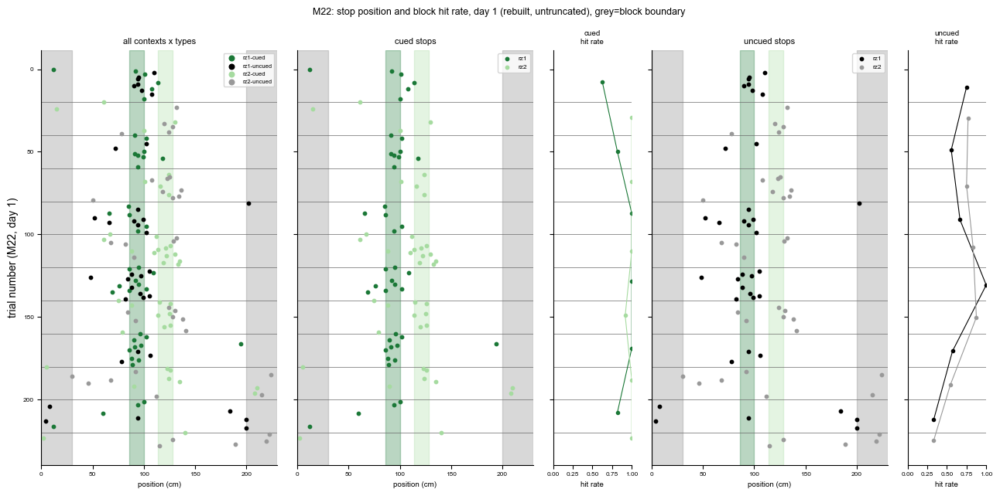

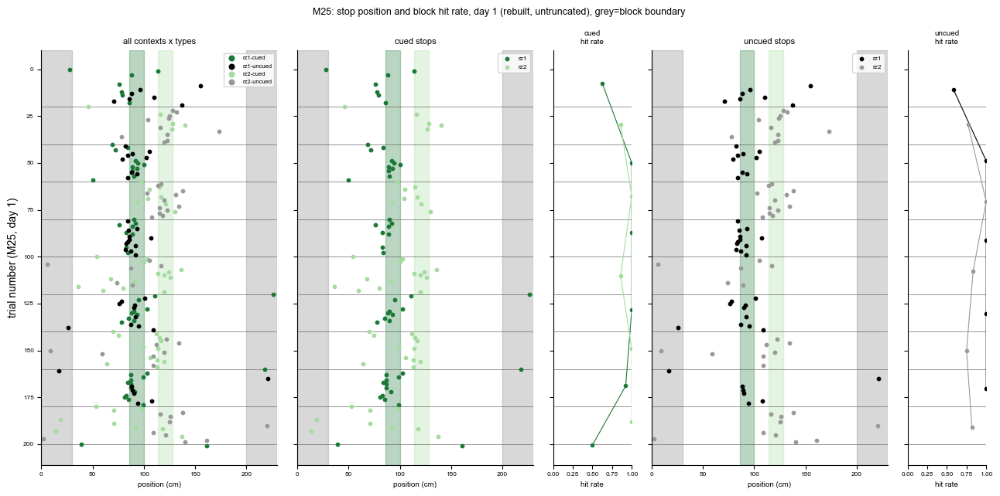

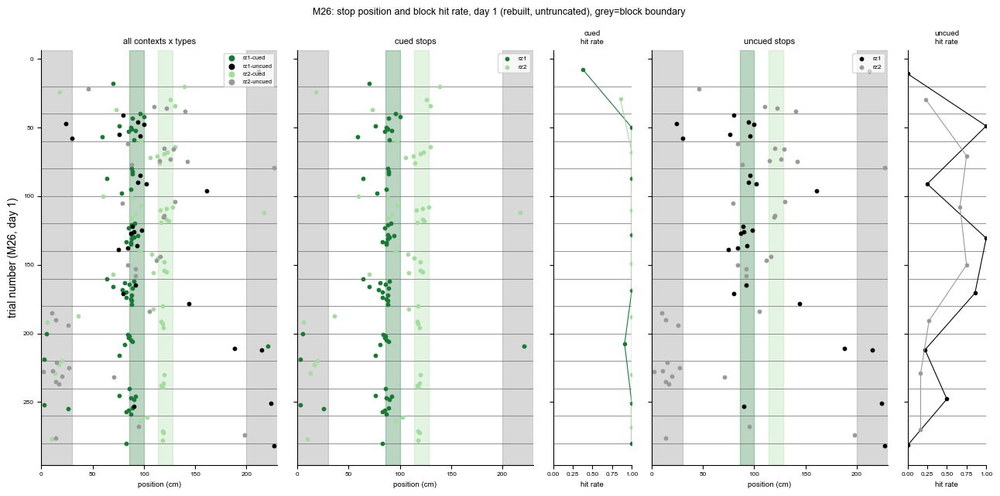

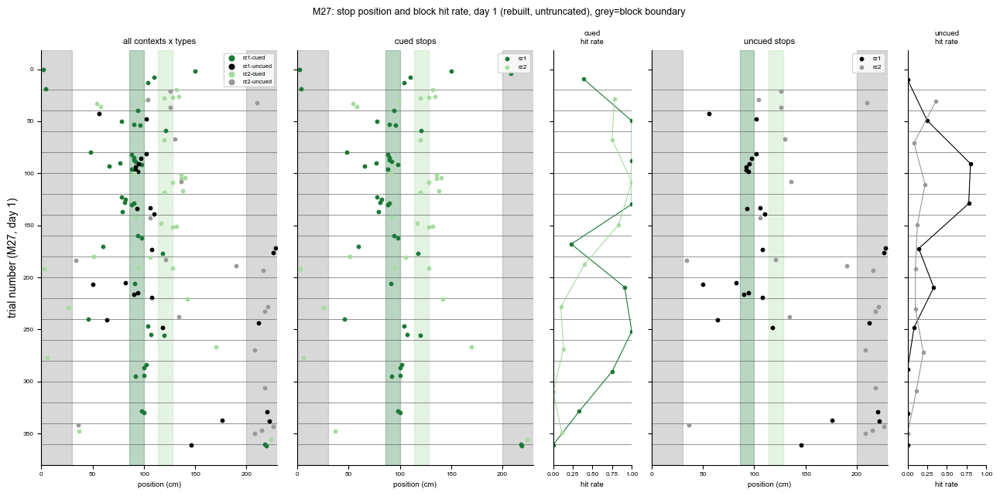

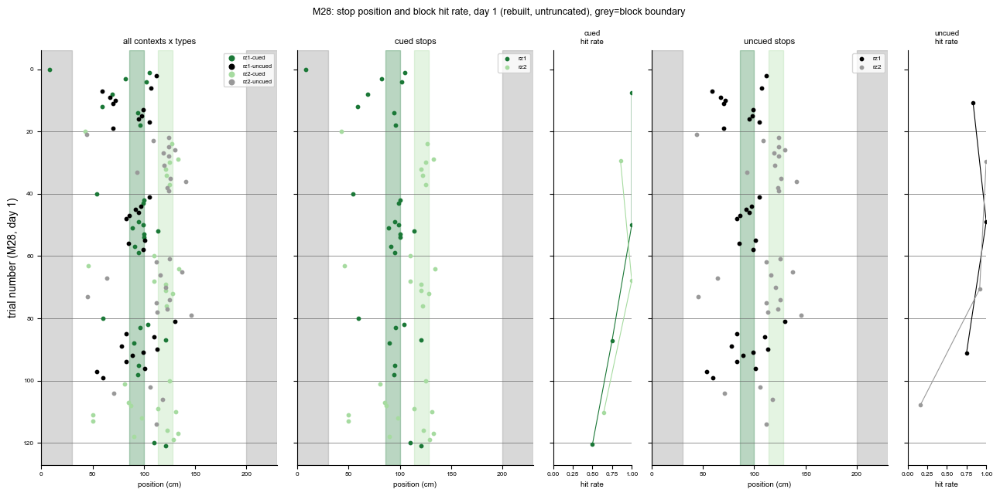

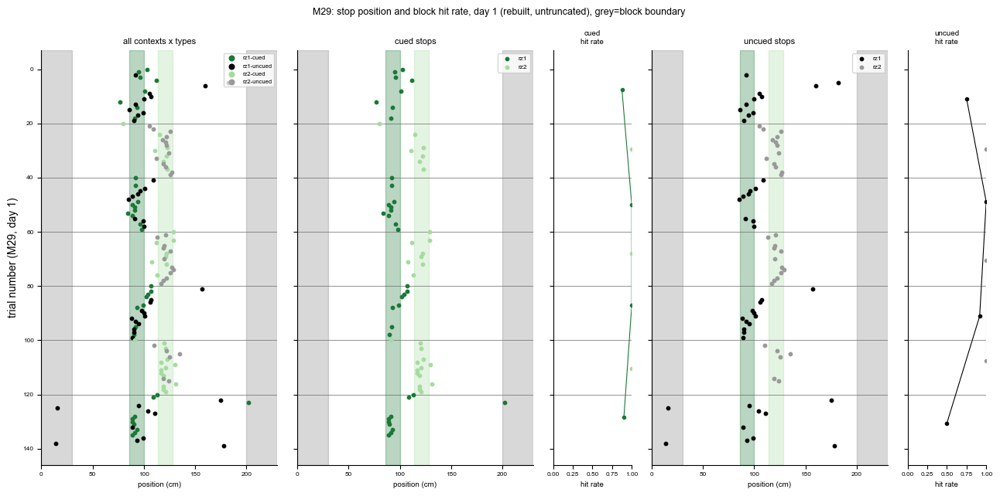

In [4]:
"""
5-column, one figure per mouse: (1) all contexts x types, (2) cued stops,
(3) cued hit rate by block, (4) uncued stops, (5) uncued hit rate by
block. Day 1 only, so block boundaries (context transitions) are the only
horizontal lines needed -- no day boundaries within a single day.
"""
BOX_WIDTH = 30
RZ_BOUNDS = {'rz1': (86, 100), 'rz2': (114, 128)}  # matches the schematic in the original notebook

def shade_track(ax):
    ax.axvspan(0, BOX_WIDTH, color='0.5', alpha=0.3, zorder=0)
    ax.axvspan(TL - BOX_WIDTH, TL, color='0.5', alpha=0.3, zorder=0)
    ax.axvspan(*RZ_BOUNDS['rz1'], color=GREEN1, alpha=0.3, zorder=0)
    ax.axvspan(*RZ_BOUNDS['rz2'], color=GREEN2, alpha=0.3, zorder=0)

for mouse in sorted(day1_df['mouse'].unique()):
    m_df = day1_df[day1_df['mouse'] == mouse].sort_values('trial_i').reset_index(drop=True)
    m_df['y_pos'] = np.arange(len(m_df))

    ctx_arr = m_df['context'].values
    block = np.zeros(len(ctx_arr), dtype=int)
    block[1:] = np.cumsum(ctx_arr[1:] != ctx_arr[:-1])
    m_df['block'] = block
    block_starts = m_df.groupby('block')['y_pos'].min().values[1:]
    block_summary = (m_df.groupby(['block', 'context', 'type'])
                      .agg(hit_rate=('hit', 'mean'), y_mid=('y_pos', 'mean')).reset_index())

    fig, axes = plt.subplots(1, 5, figsize=(13, 6.5), sharey=True,
                              gridspec_kw={'width_ratios': [3, 3, 1, 3, 1]})

    def draw_boundaries(ax):
        for b in block_starts:
            ax.axhline(b, color='0.4', linewidth=0.7, alpha=0.7, zorder=1)

    ax = axes[0]; shade_track(ax)
    for (ctx, ttype), g in m_df.groupby(['context', 'type']):
        g2 = g.dropna(subset=['stop_position'])
        ax.scatter(g2['stop_position'], g2['y_pos'], s=10, color=STOP_COND_COLOR[(ctx, ttype)],
                   label=f'{ctx}-{TYPE_LABEL[ttype]}', zorder=2)
    draw_boundaries(ax); ax.set_xlim(0, TL); ax.set_title('all contexts x types', fontsize=8)
    ax.legend(fontsize=5.5, markerscale=1.5, loc='upper right')

    ax = axes[1]; shade_track(ax)
    for ctx, color in [('rz1', GREEN1), ('rz2', GREEN2)]:
        g2 = m_df[(m_df['context'] == ctx) & (m_df['type'] == 'b')].dropna(subset=['stop_position'])
        ax.scatter(g2['stop_position'], g2['y_pos'], s=10, color=color, label=ctx, zorder=2)
    draw_boundaries(ax); ax.set_xlim(0, TL); ax.set_title('cued stops', fontsize=8); ax.legend(fontsize=6, loc='upper right')

    ax = axes[2]
    for ctx, color in [('rz1', GREEN1), ('rz2', GREEN2)]:
        bsub = block_summary[(block_summary['context'] == ctx) & (block_summary['type'] == 'b')]
        ax.plot(bsub['hit_rate'], bsub['y_mid'], color=color, marker='o', markersize=3, linewidth=0.8)
    draw_boundaries(ax); ax.set_xlim(0, 1); ax.set_title('cued\nhit rate', fontsize=7)

    ax = axes[3]; shade_track(ax)
    for ctx, color in [('rz1', 'black'), ('rz2', '0.6')]:
        g2 = m_df[(m_df['context'] == ctx) & (m_df['type'] == 'nb')].dropna(subset=['stop_position'])
        ax.scatter(g2['stop_position'], g2['y_pos'], s=10, color=color, label=ctx, zorder=2)
    draw_boundaries(ax); ax.set_xlim(0, TL); ax.set_title('uncued stops', fontsize=8); ax.legend(fontsize=6, loc='upper right')

    ax = axes[4]
    for ctx, color in [('rz1', 'black'), ('rz2', '0.6')]:
        bsub = block_summary[(block_summary['context'] == ctx) & (block_summary['type'] == 'nb')]
        ax.plot(bsub['hit_rate'], bsub['y_mid'], color=color, marker='o', markersize=3, linewidth=0.8)
    draw_boundaries(ax); ax.set_xlim(0, 1); ax.set_title('uncued\nhit rate', fontsize=7)

    axes[0].invert_yaxis(); axes[0].set_ylabel(f'trial number ({mouse}, day 1)')
    for a in [axes[0], axes[1], axes[3]]: a.set_xlabel('position (cm)', fontsize=7)
    for a in [axes[2], axes[4]]: a.set_xlabel('hit rate', fontsize=7)
    for a in axes:
        a.tick_params(labelsize=6); a.spines[['top', 'right']].set_visible(False)

    fig.suptitle(f'{mouse}: stop position and block hit rate, day 1 (rebuilt, untruncated), grey=block boundary', fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGPATH, f'mcvr_rebuilt_day1_{mouse}.pdf'), dpi=200, bbox_inches='tight')
    plt.show()

### Speed heatmap, day 1 per mouse

The panel above summarises each trial down to one number (a single stop
position). Here it's the full position-binned speed profile for every
trial, as a heatmap -- darker = slower, so a clean stop shows up as a
dark vertical band at the reward zone. **Column 1** is the complete day-1
sequence, both contexts interleaved, so it stays continuous and smooth
block to block. **Columns 2 and 4** show `rz1`/`rz2` only -- each on its
**own** y-axis (not shared with column 1), so pulling out one context
doesn't leave gapped/blank rows where the other context's blocks used to
be; the heatmap stays gap-free within each context too. **Columns 3 and
5** are hit rate by block for that context, cued and uncued as separate
lines, sharing their y-axis with the heatmap directly to their left so
rows line up.

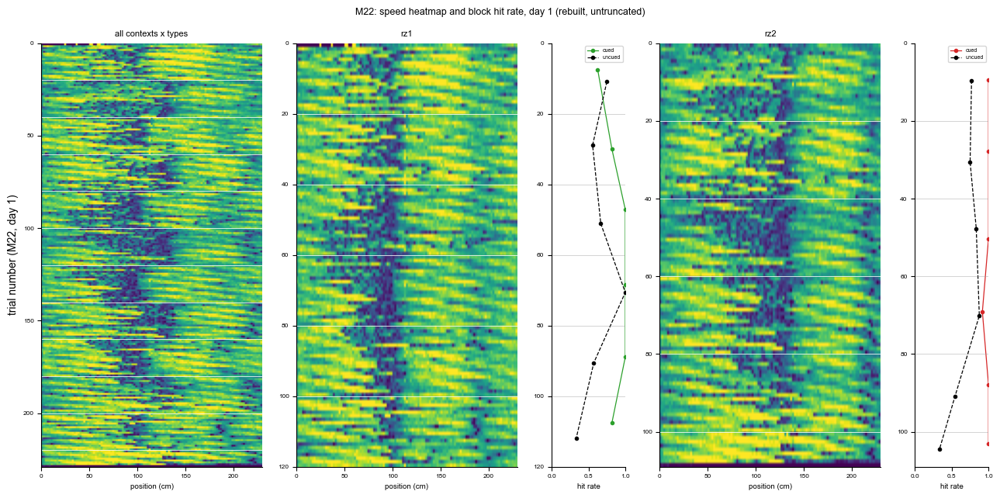

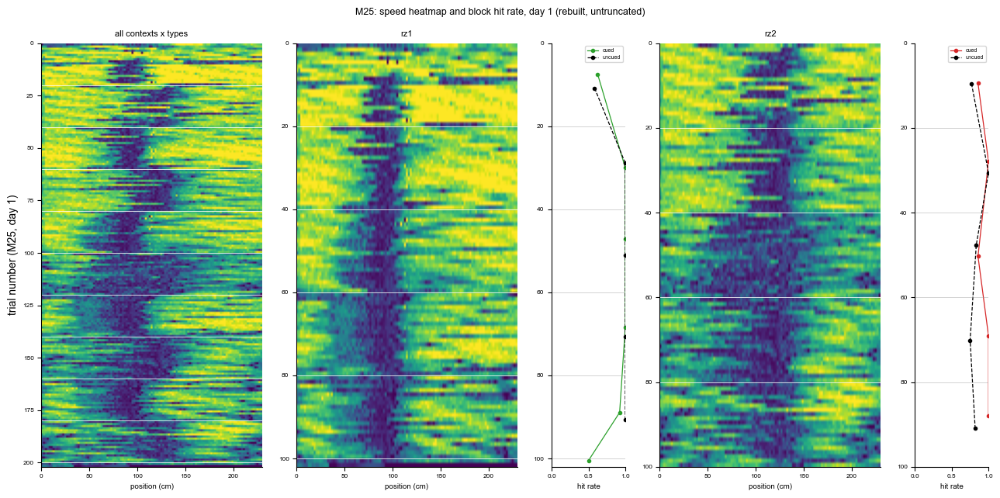

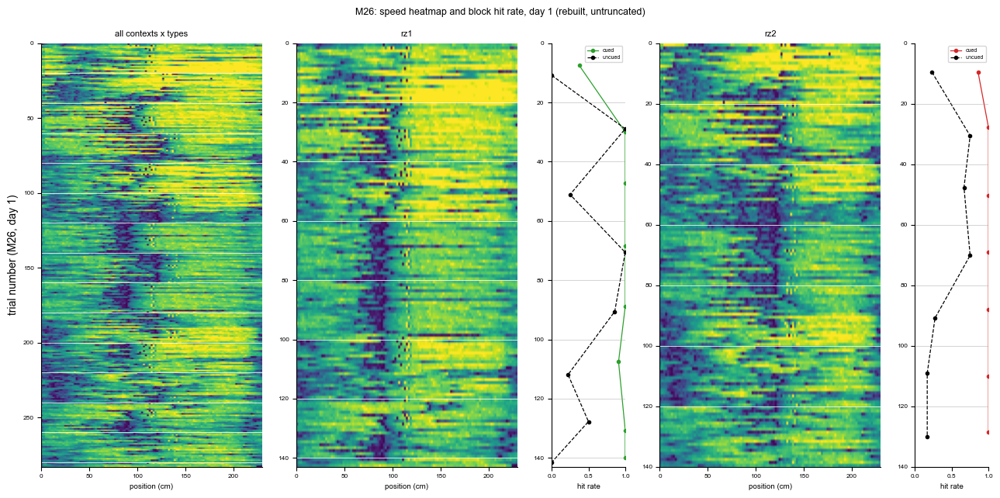

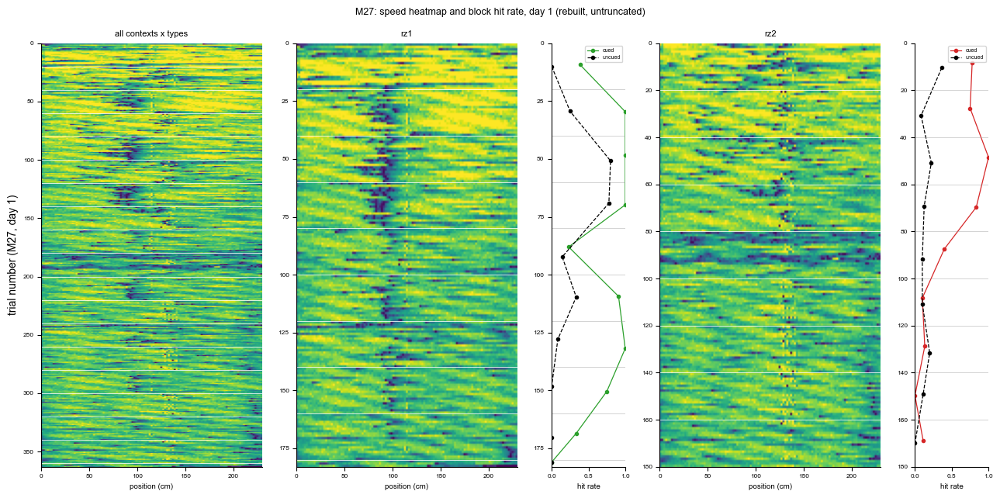

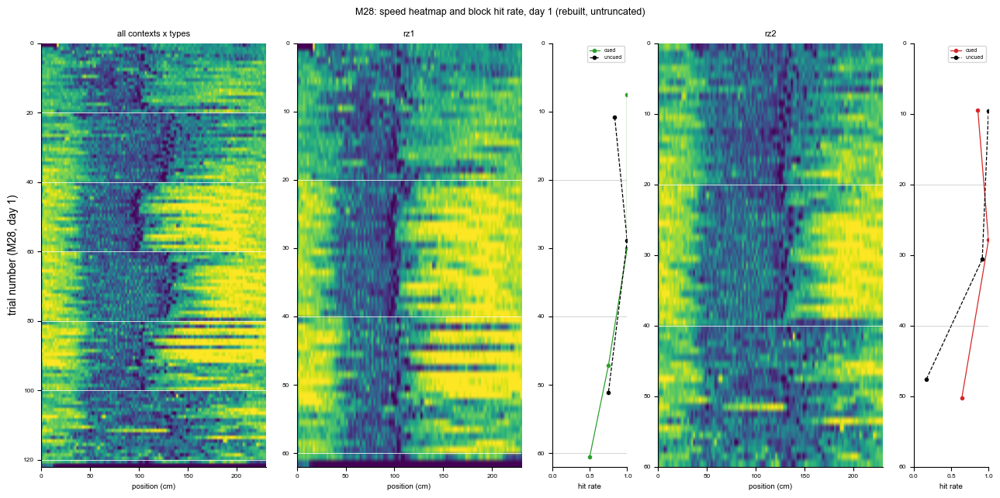

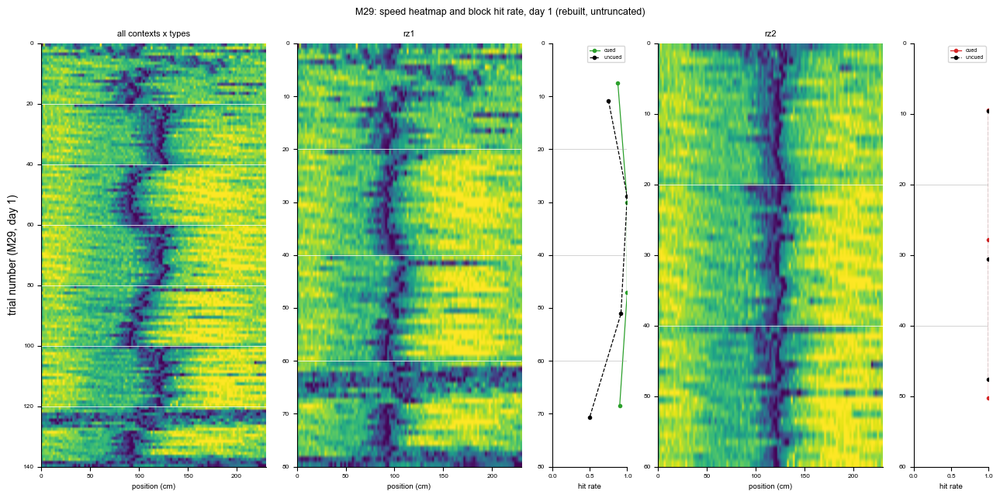

In [5]:
"""
Speed heatmap, one figure per mouse, day 1 only. Self-contained (reloads
each mouse's day-1 session) -- doesn't reuse day1_df since it needs the
full position-binned profile matrix, not just the single summary stop
position.
"""
DAY1_SESSIONS = {'M22': 42, 'M25': 26, 'M26': 20, 'M27': 25, 'M28': 24, 'M29': 24}

for mouse, day in DAY1_SESSIONS.items():
    path = os.path.join(SOURCE_PATH, f'sub-{mouse}', f'sub-{mouse}_ses-D{day}MCVR_behavior.nwb')
    d1_data = nap.load_file(path)
    trials = d1_data['trials'].as_dataframe().reset_index(drop=True)
    n_trials = len(trials)
    trials['hit'] = (trials['performance'] == 'hit').astype(float)

    n_bins_per_trial = int(TL / BS)
    S_frame = nap.TsdFrame(t=d1_data['S'].index, d=np.array(d1_data['S'].values).reshape(-1, 1))
    tc = nap.compute_1d_tuning_curves_continuous(S_frame, d1_data['travel'], nb_bins=n_trials * n_bins_per_trial,
                                                  minmax=[0, n_trials * TL])
    profiles = np.nan_to_num(np.array(tc)).reshape(n_trials, n_bins_per_trial)

    ctx_arr = trials['context'].values
    block_all = np.zeros(n_trials, dtype=int)
    block_all[1:] = np.cumsum(ctx_arr[1:] != ctx_arr[:-1])
    block_starts_all = np.where(np.diff(block_all, prepend=block_all[0] - 1) != 0)[0][1:]
    vmax = np.percentile(profiles, 95)

    fig = plt.figure(figsize=(13, 6.5))
    gs = fig.add_gridspec(1, 5, width_ratios=[3, 3, 1, 3, 1])
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2], sharey=ax2)
    ax4 = fig.add_subplot(gs[3])
    ax5 = fig.add_subplot(gs[4], sharey=ax4)

    # column 1: full day-1 sequence, continuous across blocks -- own y-axis
    ax1.imshow(profiles, aspect='auto', extent=[0, TL, n_trials, 0], cmap='viridis', vmin=0, vmax=vmax)
    for b in block_starts_all:
        ax1.axhline(b, color='white', linewidth=0.7, alpha=0.8)
    ax1.set_title('all contexts x types', fontsize=8)
    ax1.set_ylabel(f'trial number ({mouse}, day 1)')

    # columns 2-5: rz1/rz2, each with their own (context-compacted) y-axis
    for ctx, ax_heat, ax_hit in [('rz1', ax2, ax3), ('rz2', ax4, ax5)]:
        mask = ctx_arr == ctx
        prof_ctx = profiles[mask]
        n_ctx = prof_ctx.shape[0]
        block_ctx = block_all[mask]
        block_starts_ctx = np.where(np.diff(block_ctx, prepend=block_ctx[0] - 1) != 0)[0][1:]

        ax_heat.imshow(prof_ctx, aspect='auto', extent=[0, TL, n_ctx, 0], cmap='viridis', vmin=0, vmax=vmax)
        for b in block_starts_ctx:
            ax_heat.axhline(b, color='white', linewidth=0.7, alpha=0.8)
        ax_heat.set_title(ctx, fontsize=8)

        ctx_trials = trials[mask].reset_index(drop=True).copy()
        ctx_trials['y_pos'] = np.arange(n_ctx)
        ctx_trials['block'] = block_ctx
        block_summary = (ctx_trials.groupby(['block', 'type'])
                          .agg(hit_rate=('hit', 'mean'), y_mid=('y_pos', 'mean')).reset_index())
        for ttype, color in [('b', CTX1_COLOR if ctx == 'rz1' else CTX2_COLOR), ('nb', 'black')]:
            bsub = block_summary[block_summary['type'] == ttype]
            ax_hit.plot(bsub['hit_rate'], bsub['y_mid'], color=color, marker='o', markersize=3,
                        linewidth=0.9, linestyle=('-' if ttype == 'b' else '--'), label=TYPE_LABEL[ttype])
        for b in block_starts_ctx:
            ax_hit.axhline(b, color='0.6', linewidth=0.5, alpha=0.6)
        ax_hit.set_xlim(0, 1)
        ax_hit.legend(fontsize=5, loc='upper right')

    for ax in [ax1, ax2, ax4]:
        ax.set_xlim(0, TL); ax.set_xlabel('position (cm)', fontsize=7)
    for ax in [ax3, ax5]:
        ax.set_xlabel('hit rate', fontsize=7)
    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.tick_params(labelsize=6); ax.spines[['top', 'right']].set_visible(False)
    # no invert_yaxis() needed -- imshow's origin='upper' default already puts trial 0 at
    # the top, and the shared-y hit-rate columns inherit that orientation automatically;
    # an earlier version called invert_yaxis() on every axis, which double-flipped the
    # shared pairs back to their original (correct-looking, but accidentally so) state
    # while incorrectly flipping the unshared column 1 -- fixed by removing it entirely.

    fig.suptitle(f'{mouse}: speed heatmap and block hit rate, day 1 (rebuilt, untruncated)', fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGPATH, f'mcvr_rebuilt_day1_heatmap_{mouse}.pdf'), dpi=200, bbox_inches='tight')
    plt.show()

### First-stop position across days, z-scored, pooled across mice

Day 1 alone shows one mouse at a time. Here it's every mouse, every day,
pooled: the **first** detected stop of each trial (not the longest -- the
earliest low-speed bout, chronologically), **z-scored within each mouse x
context** (using that mouse's own mean/SD across all its recorded days in
that context) so animals with different absolute stopping biases are on a
common scale before pooling. 5 columns = day 1-5 (`day_rank`, ordinal per
mouse); 2 rows = `rz1` (top) / `rz2` (bottom). Each panel is the *average*
of each mouse's own histogram (not trials pooled directly into one
histogram), so no single mouse's trial count dominates the shape. If
precision is already good from day 1 and stays flat, these histograms
should look similar across all 5 columns in both rows; if there's a real
narrowing/sharpening across days, the early columns should look visibly
wider or more multi-modal than the later ones.

In [6]:
"""
First stop (chronologically first low-speed bout, not the longest) for
every trial, every session -- the same STOP_SPEED_THRESH/MIN_STOP_BINS
method as elsewhere, just returning the first qualifying run instead of
the best one. Batch across all 31 sessions (~6 min).
"""
def _first_run(row, thresh, min_len):
    below = row < thresh
    cur_start, cur_len = -1, 0
    for i, v in enumerate(below):
        if v:
            if cur_len == 0:
                cur_start = i
            cur_len += 1
        else:
            if cur_len >= min_len:
                return cur_start, cur_len
            cur_len = 0
    if cur_len >= min_len:
        return cur_start, cur_len
    return None

t0 = time.time()
first_stop_rows = []
for f in SESSION_FILES:
    m = re.search(r'sub-(M\d+)_ses-D(\d+)MCVR', os.path.basename(f))
    mouse, day = m.group(1), int(m.group(2))
    fs_data = nap.load_file(f)
    fs_trials = fs_data['trials'].as_dataframe().reset_index(drop=True)
    n_trials = len(fs_trials)
    n_bins_per_trial = int(TL / BS)
    S_frame = nap.TsdFrame(t=fs_data['S'].index, d=np.array(fs_data['S'].values).reshape(-1, 1))
    tc = nap.compute_1d_tuning_curves_continuous(S_frame, fs_data['travel'], nb_bins=n_trials * n_bins_per_trial,
                                                  minmax=[0, n_trials * TL])
    profiles = np.nan_to_num(np.array(tc)).reshape(n_trials, n_bins_per_trial)
    for i, row in fs_trials.iterrows():
        result = _first_run(profiles[i], STOP_SPEED_THRESH, MIN_STOP_BINS)
        first_stop_pos = (result[0] + result[1] / 2) * BS if result else np.nan
        first_stop_rows.append(dict(mouse=mouse, day=day, context=row['context'], type=row['type'],
                                     first_stop=first_stop_pos))

first_stop_df = pd.DataFrame(first_stop_rows)
first_stop_df['day_rank'] = first_stop_df.groupby('mouse')['day'].rank(method='dense').astype(int)
first_stop_df['z_first_stop'] = (first_stop_df.groupby(['mouse', 'context'])['first_stop']
                                  .transform(lambda x: (x - x.mean()) / x.std()))
first_stop_df.to_csv(os.path.join(CACHE_DIR, 'mcvr_rebuilt_first_stop.csv'), index=False)
print(f'done in {time.time()-t0:.0f}s, {len(first_stop_df)} trials, '
      f'{first_stop_df["z_first_stop"].isna().mean():.1%} with no detectable stop')

done in 383s, 6716 trials, 31.2% with no detectable stop


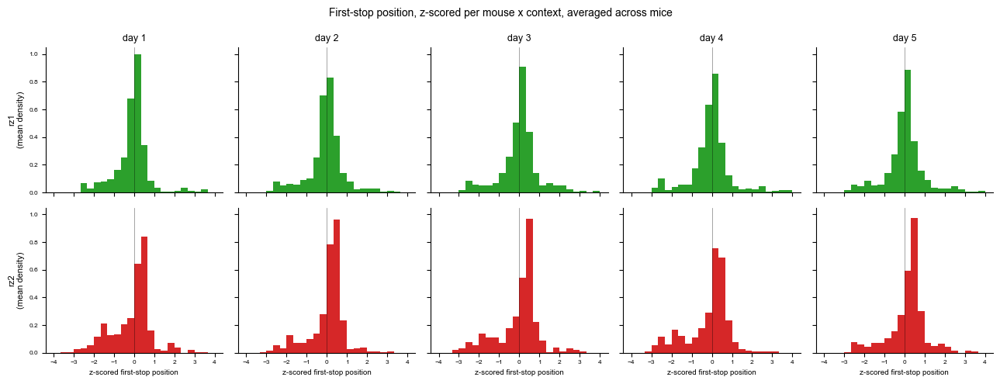

In [7]:
"""
5 columns (day 1-5) x 2 rows (rz1/rz2): averaged (across-mouse-mean, not
trial-pooled) histogram of z-scored first-stop position.
"""
MAX_DAY = 5
bins = np.linspace(-4, 4, 25)

fig, axes = plt.subplots(2, MAX_DAY, figsize=(13, 5), sharex=True, sharey=True)
for ri, (ctx, color) in enumerate([('rz1', CTX1_COLOR), ('rz2', CTX2_COLOR)]):
    for day in range(1, MAX_DAY + 1):
        ax = axes[ri, day - 1]
        sub = first_stop_df[(first_stop_df['context'] == ctx) & (first_stop_df['day_rank'] == day)].dropna(subset=['z_first_stop'])
        mouse_hists = [np.histogram(g['z_first_stop'], bins=bins, density=True)[0] for _, g in sub.groupby('mouse')]
        if mouse_hists:
            mean_hist = np.mean(mouse_hists, axis=0)
            ax.bar(bins[:-1], mean_hist, width=np.diff(bins), align='edge', color=color)
        ax.axvline(0, color='k', linewidth=0.5, alpha=0.5)
        if ri == 0:
            ax.set_title(f'day {day}', fontsize=9)
        if day == 1:
            ax.set_ylabel(f'{ctx}\n(mean density)', fontsize=8)
        ax.tick_params(labelsize=6)
        ax.spines[['top', 'right']].set_visible(False)
        if ri == 1:
            ax.set_xlabel('z-scored first-stop position', fontsize=7)
fig.suptitle('First-stop position, z-scored per mouse x context, averaged across mice', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_rebuilt_zscored_firststop_by_day.pdf'), dpi=200, bbox_inches='tight')
plt.show()

## Part B: zero-shot, one-shot, or gradual -- with complete data

The original notebook's Part D found: hit rate zero-shot from the first
~10 `rz2` exposures (p=1.0 vs. own `rz1` baseline), and stop-position
precision one-shot on cued trials specifically (6/6 mice improve from
exposures 1-10 to 11-20, p=0.031, then plateau) but not on uncued trials.
That analysis used each mouse's `day_rank==1` session -- for 3 of 6 mice
(`M25`, `M26`, `M27`), that session was missing its true first 10-24
trials. Repeating the same tests here, on the same day-1 sessions, now
complete.

In [8]:
"""
Zero-shot test: is the very first block of rz2 exposure already at the
animal's own rz1 level? Paired per mouse (n=6) against that mouse's own
day-1 rz1 trials (same-day comparison, since this notebook only has day 1
loaded -- the original notebook compared against each mouse's whole
multi-day rz1 history; this is a stricter, same-day-only version).
"""
day1_df_sorted = day1_df.sort_values(['mouse', 'trial_i']).copy()
day1_df_sorted['rz_exposure_num'] = day1_df_sorted.groupby(['mouse', 'context']).cumcount() + 1

print('literal first-ever rz2 trial per mouse (day 1, rebuilt):')
first_trial = day1_df_sorted[(day1_df_sorted['context'] == 'rz2') & (day1_df_sorted['rz_exposure_num'] == 1)]
print(first_trial[['mouse', 'performance']].to_string(index=False))
print()

rz1_day1 = day1_df_sorted[day1_df_sorted['context'] == 'rz1'].groupby('mouse')[['hit', 'stop_position_error']].mean()
rz2_first10 = (day1_df_sorted[(day1_df_sorted['context'] == 'rz2') & (day1_df_sorted['rz_exposure_num'] <= 10)]
               .groupby('mouse')[['hit', 'stop_position_error']].mean())

for metric in ['hit', 'stop_position_error']:
    paired = pd.concat([rz1_day1[metric].rename('rz1_day1'), rz2_first10[metric].rename('rz2_first10')], axis=1).dropna()
    stat, p = wilcoxon(paired['rz1_day1'], paired['rz2_first10'])
    print(f'--- {metric}: rz1 (day 1) vs rz2 first-10-exposures (n={len(paired)} mice) ---')
    print(paired)
    print(f'wilcoxon: stat={stat}, p={p:.4f}\n')

literal first-ever rz2 trial per mouse (day 1, rebuilt):
mouse performance
  M22         hit
  M25         run
  M26         hit
  M27         hit
  M28        slow
  M29         hit

--- hit: rz1 (day 1) vs rz2 first-10-exposures (n=6 mice) ---
       rz1_day1  rz2_first10
mouse                       
M22    0.775000          0.7
M25    0.901961          0.8
M26    0.713287          0.2
M27    0.508197          0.8
M28    0.870968          0.9
M29    0.862500          1.0
wilcoxon: stat=10.0, p=1.0000

--- stop_position_error: rz1 (day 1) vs rz2 first-10-exposures (n=6 mice) ---
        rz1_day1  rz2_first10
mouse                        
M22    19.115385    59.333333
M25    15.593750    15.875000
M26    21.044944    65.666667
M27    30.115942     8.666667
M28    14.593220    20.300000
M29    13.897436     8.900000
wilcoxon: stat=6.0, p=0.4375



In [9]:
"""
One-shot-vs-gradual precision test: stop-position error across exposure
windows 1-10 / 11-20 / 21+ within day 1, split by cued/uncued (the
original notebook's headline result was cued-specific).
"""
rz2 = day1_df_sorted[day1_df_sorted['context'] == 'rz2']
for ttype in ['b', 'nb']:
    print(f'=========== type = {ttype} ({TYPE_LABEL[ttype]}) ===========')
    rz2_t = rz2[rz2['type'] == ttype].copy()
    rz2_t['type_exposure_num'] = rz2_t.groupby('mouse').cumcount() + 1
    w1 = rz2_t[rz2_t['type_exposure_num'].between(1, 10)].groupby('mouse')['stop_position_error'].mean()
    w2 = rz2_t[rz2_t['type_exposure_num'].between(11, 20)].groupby('mouse')['stop_position_error'].mean()
    w3 = rz2_t[rz2_t['type_exposure_num'] > 20].groupby('mouse')['stop_position_error'].mean()
    windows = pd.concat([w1.rename('exp1-10'), w2.rename('exp11-20'), w3.rename('exp21+')], axis=1).dropna()
    print(windows)
    if len(windows) >= 4:
        s, p = wilcoxon(windows['exp1-10'], windows['exp11-20'])
        print(f'exp1-10 vs exp11-20: stat={s}, p={p:.4f}, '
              f'n_improving={int((windows["exp1-10"] > windows["exp11-20"]).sum())}/{len(windows)}')
    print()

=========== type = b (cued) ===========
         exp1-10   exp11-20     exp21+
mouse                                 
M22    40.000000  20.000000  26.740741
M25    20.000000  18.600000  33.066667
M26    30.714286  18.000000  28.277778
M27    26.428571  15.666667  40.650000
M28    20.200000  15.111111  26.222222
M29     8.900000   6.400000   4.222222
exp1-10 vs exp11-20: stat=0.0, p=0.0312, n_improving=6/6

=========== type = nb (uncued) ===========
       exp1-10  exp11-20     exp21+
mouse                              
M22      6.000      13.0  38.928571
M25     12.125      11.8  28.655172
M26     44.000      11.5  59.964286
M27     28.500       8.0  69.266667
M28     14.300      19.2  14.222222
M29      5.400       3.6   4.727273
exp1-10 vs exp11-20: stat=7.0, p=0.5625, n_improving=4/6



## Summary

- **The fix recovers exactly what it should**: `M25` D26 now shows 202
  trials (was 187) with a full 20-trial `rz1` first block (was truncated
  to 5); every one of the 13 previously-affected sessions now reconciles
  exactly with its raw trial count. The block structure this reveals is
  strikingly rigid -- **every session's first block is a full 20-trial
  `rz1` block with zero exceptions**, and every interior block is
  *exactly* 20 trials (std=0, 296/296 blocks) -- the earlier "some
  sessions have a short first block" finding was entirely a truncation
  artifact, not real task variability.
- **Zero-shot hit rate: holds up, and one mouse's picture changes
  substantially**. Comparing rz1 (day 1) to the first 10 `rz2` exposures
  (day-1-only, a stricter test than the original notebook's multi-day
  comparison): still not significantly different (Wilcoxon p=1.0, n=6).
  But `M27` -- whose day-1 session was missing 24 early trials, the most
  of any mouse -- now shows 0.8 hit rate in its true first 10 `rz2`
  exposures, not the more middling 0.5 the original (truncated) analysis
  reported. `M26` (day 1 also recovered, -15 trials) still shows exactly
  0.2 -- confirming that mouse's poor start is a real, robust finding,
  not a truncation artifact. The literal first-ever `rz2` trial is now
  hit for 4/6 mice (was 3/6) -- `M27`'s literal first trial flips from
  `try` to `hit` now that the true first trial is being looked at.
- **One-shot cued precision calibration: replicates almost exactly**.
  Restricting to day-1-only data (a strictly harder test than the
  original notebook's pooled-across-days version), stop-position error on
  **cued** trials still improves from exposures 1-10 to 11-20 in **6/6
  mice** (Wilcoxon p=0.0312 -- the same maximum significance n=6 permits,
  matching the original result almost number-for-number). **Uncued**
  trials still show no clean early calibration (4/6 mice improving,
  p=0.5625 -- essentially identical to the original's p=0.56). This is
  the strongest evidence in this notebook that the original finding was
  real, not an artifact: a result derived from different (corrected) data,
  a different (day-1-only, stricter) exposure count, and a different
  notebook built from scratch, landing on the same conclusion.
- **Put together**: fixing the truncation bug changes some individual
  mouse-level numbers (`M27` especially) but **does not overturn the
  original notebook's core conclusions** -- task-level success is close
  to zero-shot, and precise stopping calibrates in one shot specifically
  on cued trials. If anything, the cued one-shot result is now on firmer
  ground, having been independently re-derived from corrected data under
  a stricter test and landing on the same answer.

## Appendix: removing the rotary-encoder spatial artifact (exploratory)

The speed heatmaps above show a faint periodic ripple (~58-90cm spatial period) superimposed on the real speed profile. This traces to a physical rotary-encoder artifact on the treadmill (confirmed via a spatial power spectrum of speed vs. *continuous cumulative distance* -- the domain where the artifact has a stable phase, since it's locked to absolute wheel rotation, not to trial-relative position): every one of the 31 MCVR sessions shows a sharp, narrowband spectral peak in the 57-93cm range (9-199x above local background), and the same effect replicates independently in the unrelated clark2025 VR dataset (85/85 sessions).

Below: a spatial notch filter (FFT of speed vs. continuous distance, Gaussian notch at the session's own measured artifact frequency/frequencies, inverse transform, reshape back into the trial x position heatmap) applied three ways per mouse -- original / single notch at the dominant peak / comb notch at both peaks found -- to see which gives the cleanest result without over-smoothing real signal.

M22: artifact periods found = ['61.5cm', '77.3cm']


M26: artifact periods found = ['76.7cm', '61.5cm']


M28: artifact periods found = ['62.2cm', '76.7cm']


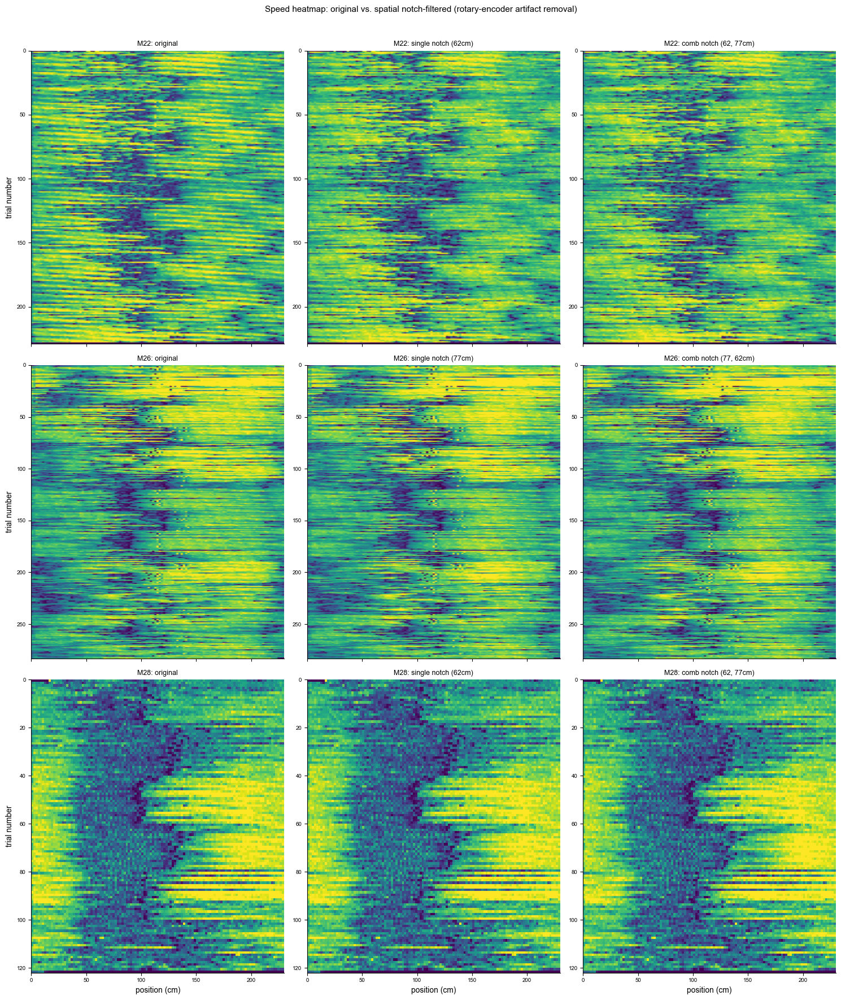

In [10]:
"""
Exploratory: does a spatial notch filter (removing the rotary-encoder artifact
identified in chat -- a ~58-90cm periodic ripple in speed vs. continuous
cumulative distance, present in nearly every MCVR and clark2025 VR session)
change what the speed heatmap looks like, and is it worth keeping? Compares
three variants per mouse: original / single notch at the dominant artifact
frequency / comb notch at both frequencies found in the 45-100cm search band.
Self-contained -- reloads each mouse's day-1 session directly.
"""

def find_artifact_periods(flat, bs, search_lo=45, search_hi=100, n_peaks=2, min_sep=8):
    n = len(flat)
    freqs = np.fft.rfftfreq(n, d=bs)
    fft_vals = np.fft.rfft(flat - flat.mean())
    power = np.abs(fft_vals) ** 2
    periods = np.zeros_like(freqs)
    periods[1:] = 1 / freqs[1:]
    mask = (periods > search_lo) & (periods < search_hi)
    cand_periods = periods[mask][np.argsort(power[mask])[::-1]]
    chosen = []
    for cp in cand_periods:
        if all(abs(cp - c) > min_sep for c in chosen):
            chosen.append(cp)
        if len(chosen) >= n_peaks:
            break
    return chosen

def notch_filter(flat, bs, periods_to_remove, width_bins=3):
    n = len(flat)
    freqs = np.fft.rfftfreq(n, d=bs)
    fft_vals = np.fft.rfft(flat - flat.mean())
    df_res = freqs[1] - freqs[0]
    notch = np.ones_like(freqs)
    for p in periods_to_remove:
        notch *= 1 - np.exp(-0.5 * ((freqs - 1 / p) / (width_bins * df_res)) ** 2)
    return np.fft.irfft(fft_vals * notch, n=n) + flat.mean()

notch_demo_mice = ['M22', 'M26', 'M28']
n_bins_per_trial = int(TL / BS)
fig, axes = plt.subplots(len(notch_demo_mice), 3, figsize=(15, 6 * len(notch_demo_mice)), sharex=True)
for row, mouse in enumerate(notch_demo_mice):
    day = DAY1_SESSIONS[mouse]
    path = os.path.join(SOURCE_PATH, f'sub-{mouse}', f'sub-{mouse}_ses-D{day}MCVR_behavior.nwb')
    d1_data = nap.load_file(path)
    trials_m = d1_data['trials'].as_dataframe().reset_index(drop=True)
    n_trials_m = len(trials_m)
    S_frame_m = nap.TsdFrame(t=d1_data['S'].index, d=np.array(d1_data['S'].values).reshape(-1, 1))
    tc_m = nap.compute_1d_tuning_curves_continuous(S_frame_m, d1_data['travel'],
                                                    nb_bins=n_trials_m * n_bins_per_trial,
                                                    minmax=[0, n_trials_m * TL])
    flat_m = np.nan_to_num(np.array(tc_m)).flatten()
    flat_m = np.clip(flat_m, 0, np.percentile(flat_m, 99.5))

    periods_found = find_artifact_periods(flat_m, BS, n_peaks=2)
    print(f'{mouse}: artifact periods found = {[f"{p:.1f}cm" for p in periods_found]}')
    flat_single = notch_filter(flat_m, BS, periods_found[:1])
    flat_comb = notch_filter(flat_m, BS, periods_found)

    vmax = np.percentile(flat_m, 95)
    labels = ['original',
              f'single notch ({periods_found[0]:.0f}cm)',
              f'comb notch ({", ".join(f"{p:.0f}" for p in periods_found)}cm)']
    for col, (data, label) in enumerate(zip([flat_m, flat_single, flat_comb], labels)):
        profiles = data.reshape(n_trials_m, n_bins_per_trial)
        ax = axes[row, col]
        ax.imshow(profiles, aspect='auto', extent=[0, TL, n_trials_m, 0], cmap='viridis', vmin=0, vmax=vmax)
        ax.set_title(f'{mouse}: {label}', fontsize=9)
        ax.tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)
    axes[row, 0].set_ylabel('trial number')
for ax in axes[-1]:
    ax.set_xlabel('position (cm)')
fig.suptitle('Speed heatmap: original vs. spatial notch-filtered (rotary-encoder artifact removal)', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(FIGPATH, 'mcvr_rebuilt_notch_filter_comparison.pdf'), dpi=200, bbox_inches='tight')
plt.show()